<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [9]:
# Cargar los datos de housing desde una fuente más completa para incluir 'ocean_proximity'
# y permitir etapas de preprocesamiento, como se indica en el problema.
housing = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv')

# Renombrar la columna 'housing_median_age' a 'housingmedianage' para coincidir con la descripción del problema
housing.rename(columns={'housing_median_age': 'housingmedianage'}, inplace=True)

# Renombrar la columna 'median_house_value' a 'medianhousevalue' para coincidir con la descripción del problema
housing.rename(columns={'median_house_value': 'medianhousevalue'}, inplace=True)

# Visualizar las primeras filas del DataFrame
housing.head()

,longitude,latitude,housingmedianage,total_rooms,total_bedrooms,population,households,median_income,medianhousevalue,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
print(housing.info())
display(housing.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   longitude         20640 non-null  float64
 1   latitude          20640 non-null  float64
 2   housingmedianage  20640 non-null  float64
 3   total_rooms       20640 non-null  float64
 4   total_bedrooms    20433 non-null  float64
 5   population        20640 non-null  float64
 6   households        20640 non-null  float64
 7   median_income     20640 non-null  float64
 8   medianhousevalue  20640 non-null  float64
 9   ocean_proximity   20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


,longitude,latitude,housingmedianage,total_rooms,total_bedrooms,population,households,median_income,medianhousevalue,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


### Visualización descriptiva

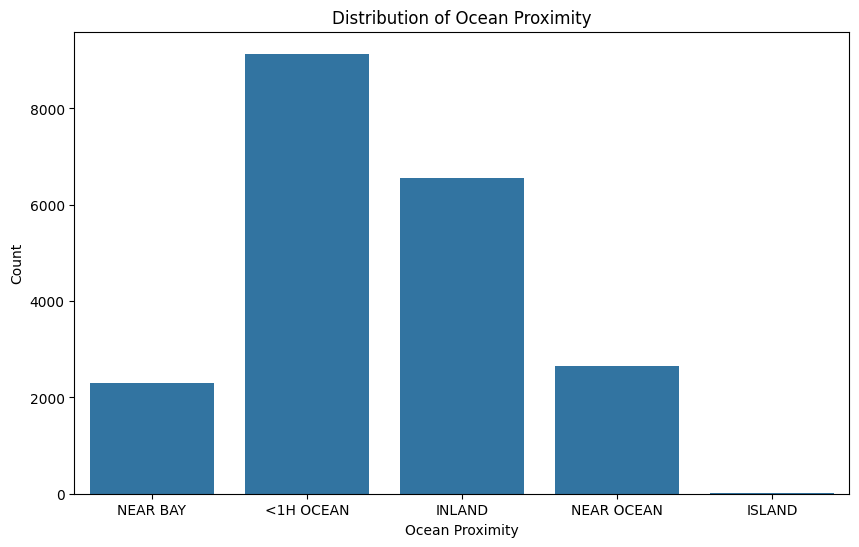

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=housing, x='ocean_proximity')
plt.title('Distribution of Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Count')
plt.show()

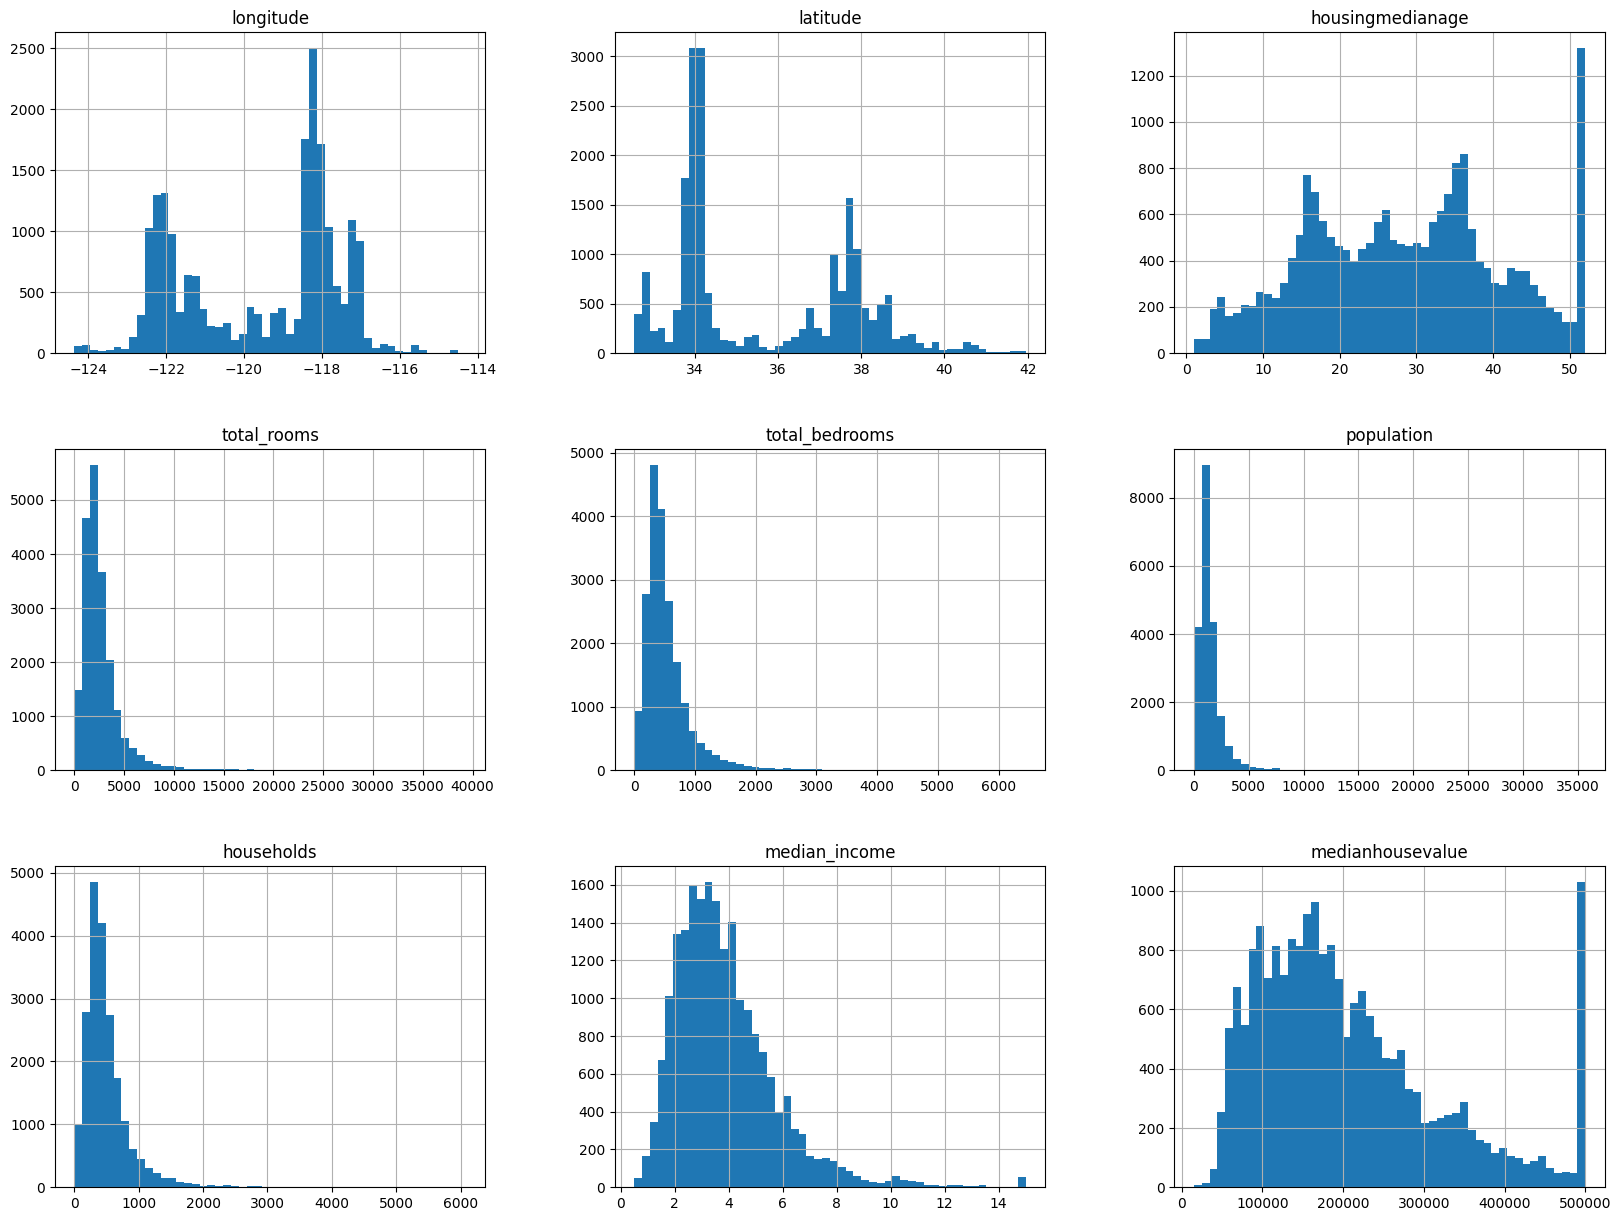

In [12]:
housing.hist(bins=50, figsize=(20, 15))
plt.show()

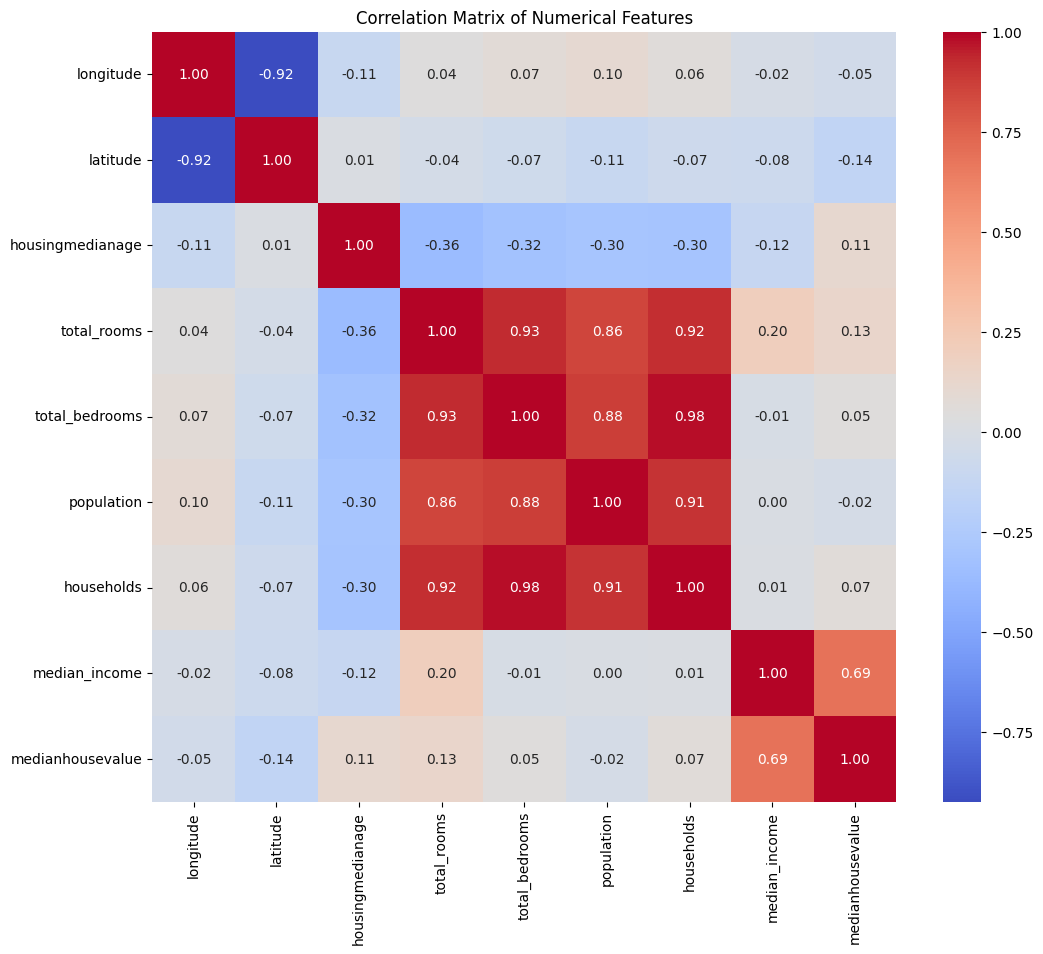

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(housing.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Preprocesamiento

In [14]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# Create a copy of the data without the categorical attribute 'ocean_proximity'
housing_num = housing.drop("ocean_proximity", axis=1)

# Fit the imputer on numerical data
imputer.fit(housing_num)

# Transform the numerical data
X = imputer.transform(housing_num)

# Put the transformed data back into a DataFrame
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

# Check for missing values after imputation
print("Missing values after imputation:")
print(housing_tr.isnull().sum())

Missing values after imputation:
longitude           0
latitude            0
housingmedianage    0
total_rooms         0
total_bedrooms      0
population          0
households          0
median_income       0
medianhousevalue    0
dtype: int64


In [15]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing[['ocean_proximity']]

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# Combine numerical and one-hot encoded categorical features
housing_prepared = pd.concat([housing_tr, pd.DataFrame(housing_cat_1hot, columns=cat_encoder.get_feature_names_out(['ocean_proximity']), index=housing_tr.index)], axis=1)

print("Shape of prepared data:", housing_prepared.shape)
display(housing_prepared.head())

Shape of prepared data: (20640, 14)


,longitude,latitude,housingmedianage,total_rooms,total_bedrooms,population,households,median_income,medianhousevalue,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = housing_prepared.drop('medianhousevalue', axis=1)
y = housing_prepared['medianhousevalue']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Apply feature scaling to numerical features
scaler = StandardScaler()

# Identify numerical columns for scaling (excluding one-hot encoded columns and target)
numerical_cols = housing_num.drop('medianhousevalue', axis=1).columns

# Scale numerical features
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nFirst 5 rows of scaled X_train (numerical features):")
display(X_train[numerical_cols].head())

Shape of X_train: (16512, 13)
Shape of X_test: (4128, 13)
Shape of y_train: (16512,)
Shape of y_test: (4128,)

First 5 rows of scaled X_train (numerical features):


,longitude,latitude,housingmedianage,total_rooms,total_bedrooms,population,households,median_income
14196,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196
8267,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843
17445,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701
14265,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864
2271,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488


### Selección de modelo

#### Modelo 1: Regresión Lineal

In [50]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Linear Regression model trained.")

Linear Regression model trained.


#### Evaluación del Modelo 1: Regresión Lineal

In [51]:
# Make predictions on the training set
y_train_pred_lin_reg = lin_reg.predict(X_train)

# Make predictions on the test set
y_test_pred_lin_reg = lin_reg.predict(X_test)

print("Predictions made for Linear Regression model.")

Predictions made for Linear Regression model.


In [52]:
print("Linear Regression - Training Set Metrics:")
df_train_lin_reg = pd.DataFrame({'y': y_train, 'yhat': y_train_pred_lin_reg})
display(regression_metrics(df_train_lin_reg))

print("\nLinear Regression - Test Set Metrics:")
df_test_lin_reg = pd.DataFrame({'y': y_test, 'yhat': y_test_pred_lin_reg})
display(regression_metrics(df_test_lin_reg))

Linear Regression - Training Set Metrics:


,mae,mse,rmse,mape,smape
0,49594.8421,4.683204e+09,68433.9374,28.5426,0.4441



Linear Regression - Test Set Metrics:


,mae,mse,rmse,mape,smape
0,50670.7382,4.908477e+09,70060.5218,29.1907,0.4519


#### Modelo 2: Árbol de Decisión para Regresión

In [53]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

print("Decision Tree Regressor model trained.")

Decision Tree Regressor model trained.


#### Evaluación del Modelo 2: Árbol de Decisión para Regresión

In [54]:
# Make predictions on the training set
y_train_pred_tree_reg = tree_reg.predict(X_train)

# Make predictions on the test set
y_test_pred_tree_reg = tree_reg.predict(X_test)

print("Predictions made for Decision Tree Regressor model.")

Predictions made for Decision Tree Regressor model.


In [55]:
print("Decision Tree Regressor - Training Set Metrics:")
df_train_tree_reg = pd.DataFrame({'y': y_train, 'yhat': y_train_pred_tree_reg})
display(regression_metrics(df_train_tree_reg))

print("\nDecision Tree Regressor - Test Set Metrics:")
df_test_tree_reg = pd.DataFrame({'y': y_test, 'yhat': y_test_pred_tree_reg})
display(regression_metrics(df_test_tree_reg))

Decision Tree Regressor - Training Set Metrics:


,mae,mse,rmse,mape,smape
0,0.0,0.0,0.0,0.0,0.0



Decision Tree Regressor - Test Set Metrics:


,mae,mse,rmse,mape,smape
0,43550.4048,4.771876e+09,69078.7652,24.1108,0.3885


#### Resumen de Métricas de Modelos de Regresión

In [57]:
all_models_metrics = {
    'Linear Regression': {
        'Train': regression_metrics(df_train_lin_reg).iloc[0].to_dict(),
        'Test': regression_metrics(df_test_lin_reg).iloc[0].to_dict()
    },
    'Decision Tree Regressor': {
        'Train': regression_metrics(df_train_tree_reg).iloc[0].to_dict(),
        'Test': regression_metrics(df_test_tree_reg).iloc[0].to_dict()
    },
    'Random Forest Regressor': {
        'Train': regression_metrics(pd.DataFrame({'y': y_train, 'yhat': y_train_pred_forest_reg})).iloc[0].to_dict(),
        'Test': regression_metrics(pd.DataFrame({'y': y_test, 'yhat': y_test_pred_forest_reg})).iloc[0].to_dict()
    },
    'Gradient Boosting Regressor': {
        'Train': regression_metrics(pd.DataFrame({'y': y_train, 'yhat': y_train_pred_gbrt})).iloc[0].to_dict(),
        'Test': regression_metrics(pd.DataFrame({'y': y_test, 'yhat': y_test_pred_gbrt})).iloc[0].to_dict()
    }
}

# Create a DataFrame to display the metrics
metrics_df = pd.DataFrame()

for model_name, metrics_data in all_models_metrics.items():
    for subset, metrics in metrics_data.items():
        row = {'Model': model_name, 'Subset': subset}
        row.update(metrics)
        metrics_df = pd.concat([metrics_df, pd.DataFrame([row])], ignore_index=True)

display(metrics_df)

print("Summary of regression model metrics generated.")

,Model,Subset,mae,mse,rmse,mape,smape
0,Linear Regression,Train,49594.8421,4.683204e+09,68433.9374,28.5426,0.4441
1,Linear Regression,Test,50670.7382,4.908477e+09,70060.5218,29.1907,0.4519
2,Decision Tree Regressor,Train,0.0000,0.000000e+00,0.0000,0.0000,0.0000
3,Decision Tree Regressor,Test,43550.4048,4.771876e+09,69078.7652,24.1108,0.3885
4,Random Forest Regressor,Train,11641.4387,3.266410e+08,18073.2134,6.4762,0.1216
5,Random Forest Regressor,Test,31628.5924,2.395315e+09,48941.9547,17.7447,0.3014
6,Gradient Boosting Regressor,Train,36970.2983,2.798549e+09,52901.3139,20.7448,0.3436
7,Gradient Boosting Regressor,Test,38250.0153,3.122773e+09,55881.7761,21.4712,0.3535


Summary of regression model metrics generated.


### Conclusiones de Regresión

Basándonos en las métricas de rendimiento en el conjunto de prueba (`Test`), podemos observar lo siguiente:

*   **Linear Regression** es el modelo con el peor rendimiento general, con los valores más altos de MAE, MSE, RMSE, MAPE y SMAPE en el conjunto de prueba.
*   **Decision Tree Regressor** muestra un rendimiento excelente en el conjunto de entrenamiento (MAE, MSE, RMSE, MAPE, SMAPE = 0), lo que es un claro indicio de **sobreajuste (overfitting)**. Sin embargo, su rendimiento en el conjunto de prueba es significativamente mejor que el de la Regresión Lineal.
*   **Random Forest Regressor** y **Gradient Boosting Regressor** tienen un rendimiento superior en el conjunto de prueba comparado con los dos modelos anteriores. Ambos modelos de ensamble son más robustos contra el sobreajuste y generalmente ofrecen mejores resultados.
*   Comparando **Random Forest Regressor** y **Gradient Boosting Regressor** en el conjunto de prueba, el **Random Forest Regressor** parece tener métricas ligeramente mejores (menor MAE, MSE, RMSE, MAPE y SMAPE), sugiriendo que podría ser el mejor modelo entre los evaluados para este problema de regresión. También es importante notar que el Gradient Boosting tiene un sobreajuste menos pronunciado en el conjunto de entrenamiento que el Random Forest.

En resumen, para la tarea de regresión, el **Random Forest Regressor** parece ser el modelo más prometedor debido a su equilibrio entre el rendimiento en entrenamiento y prueba, y su capacidad para manejar la complejidad del dataset de forma más efectiva que los modelos simples. Sin embargo, el sobreajuste del Random Forest es una señal de que podría beneficiarse de la optimización de hiperparámetros o la adición de más datos de entrenamiento.

#### Modelo 3: Random Forest Regressor

In [59]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train, y_train)

print("Random Forest Regressor model trained.")

Random Forest Regressor model trained.


#### Evaluación del Modelo 3: Random Forest Regressor

In [60]:
# Make predictions on the training set
y_train_pred_forest_reg = forest_reg.predict(X_train)

# Make predictions on the test set
y_test_pred_forest_reg = forest_reg.predict(X_test)

print("Predictions made for Random Forest Regressor model.")

Predictions made for Random Forest Regressor model.


In [61]:
print("Random Forest Regressor - Training Set Metrics:")
df_train_forest_reg = pd.DataFrame({'y': y_train, 'yhat': y_train_pred_forest_reg})
display(regression_metrics(df_train_forest_reg))

print("\nRandom Forest Regressor - Test Set Metrics:")
df_test_forest_reg = pd.DataFrame({'y': y_test, 'yhat': y_test_pred_forest_reg})
display(regression_metrics(df_test_forest_reg))

Random Forest Regressor - Training Set Metrics:


,mae,mse,rmse,mape,smape
0,11641.4387,3.266410e+08,18073.2134,6.4762,0.1216



Random Forest Regressor - Test Set Metrics:


,mae,mse,rmse,mape,smape
0,31628.5924,2.395315e+09,48941.9547,17.7447,0.3014


#### Modelo 4: Gradient Boosting Regressor

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(random_state=42)
gbrt.fit(X_train, y_train)

print("Gradient Boosting Regressor model trained.")

Gradient Boosting Regressor model trained.


#### Evaluación del Modelo 4: Gradient Boosting Regressor

In [63]:
# Make predictions on the training set
y_train_pred_gbrt = gbrt.predict(X_train)

# Make predictions on the test set
y_test_pred_gbrt = gbrt.predict(X_test)

print("Predictions made for Gradient Boosting Regressor model.")

Predictions made for Gradient Boosting Regressor model.


In [64]:
print("Gradient Boosting Regressor - Training Set Metrics:")
df_train_gbrt = pd.DataFrame({'y': y_train, 'yhat': y_train_pred_gbrt})
display(regression_metrics(df_train_gbrt))

print("\nGradient Boosting Regressor - Test Set Metrics:")
df_test_gbrt = pd.DataFrame({'y': y_test, 'yhat': y_test_pred_gbrt})
display(regression_metrics(df_test_gbrt))

Gradient Boosting Regressor - Training Set Metrics:


,mae,mse,rmse,mape,smape
0,36970.2983,2.798549e+09,52901.3139,20.7448,0.3436



Gradient Boosting Regressor - Test Set Metrics:


,mae,mse,rmse,mape,smape
0,38250.0153,3.122773e+09,55881.7761,21.4712,0.3535


## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

### Transición a Clasificación

Con la sección de regresión concluida, ahora nos adentraremos en la tarea de **Clasificación**. Utilizaremos el conjunto de datos de dígitos (`digits_dict`) y aplicaremos al menos tres modelos de clasificación, evaluándolos con métricas como Accuracy, Precision, Recall y F1-score.

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [65]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [66]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [67]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [68]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8])

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [69]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [70]:
print("### 1. ¿Cómo se distribuyen los datos? (Estadísticas Descriptivas)\n")
display(digits.describe())

print("\n### 2. ¿Cuánta memoria estoy utilizando? (Uso de Memoria)\n")
print(digits.info(memory_usage='deep'))

print("\n### 3. ¿Qué tipo de datos son? (Tipos de Datos)\n")
print(digits.dtypes)

print("\n### 4. ¿Cuántos registros por clase hay? (Distribución de Clases)\n")
display(digits['target'].value_counts().sort_index())

print("\n### 5. ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?\n")
print("Los valores de píxeles (c00-c63) deberían estar entre 0 y 16 (inclusive) para este dataset de dígitos. El rango mostrado en .describe() confirma esto. No hay valores atípicos evidentes que contradigan el conocimiento previo.")

### 1. ¿Cómo se distribuyen los datos? (Estadísticas Descriptivas)



,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000



### 2. ¿Cuánta memoria estoy utilizando? (Uso de Memoria)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 non-null   int64
 19  c19     1797 non-null   int64
 20  c20     1797 non-null   int64
 21  c21     1797 non-null  

,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174



### 5. ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

Los valores de píxeles (c00-c63) deberían estar entre 0 y 16 (inclusive) para este dataset de dígitos. El rango mostrado en .describe() confirma esto. No hay valores atípicos evidentes que contradigan el conocimiento previo.


In [71]:
print("### 1. ¿Cómo se distribuyen los datos? (Estadísticas Descriptivas)\n")
display(digits.describe())

print("\n### 2. ¿Cuánta memoria estoy utilizando? (Uso de Memoria)\n")
print(digits.info(memory_usage='deep'))

print("\n### 3. ¿Qué tipo de datos son? (Tipos de Datos)\n")
print(digits.dtypes)

print("\n### 4. ¿Cuántos registros por clase hay? (Distribución de Clases)\n")
display(digits['target'].value_counts().sort_index())

print("\n### 5. ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?\n")
print("Los valores de píxeles (c00-c63) deberían estar entre 0 y 16 (inclusive) para este dataset de dígitos. El rango mostrado en .describe() confirma esto. No hay valores atípicos evidentes que contradigan el conocimiento previo.")

### 1. ¿Cómo se distribuyen los datos? (Estadísticas Descriptivas)



,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000



### 2. ¿Cuánta memoria estoy utilizando? (Uso de Memoria)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 non-null   int64
 19  c19     1797 non-null   int64
 20  c20     1797 non-null   int64
 21  c21     1797 non-null  

,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174



### 5. ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

Los valores de píxeles (c00-c63) deberían estar entre 0 y 16 (inclusive) para este dataset de dígitos. El rango mostrado en .describe() confirma esto. No hay valores atípicos evidentes que contradigan el conocimiento previo.


### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [72]:
digits_dict["images"][0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

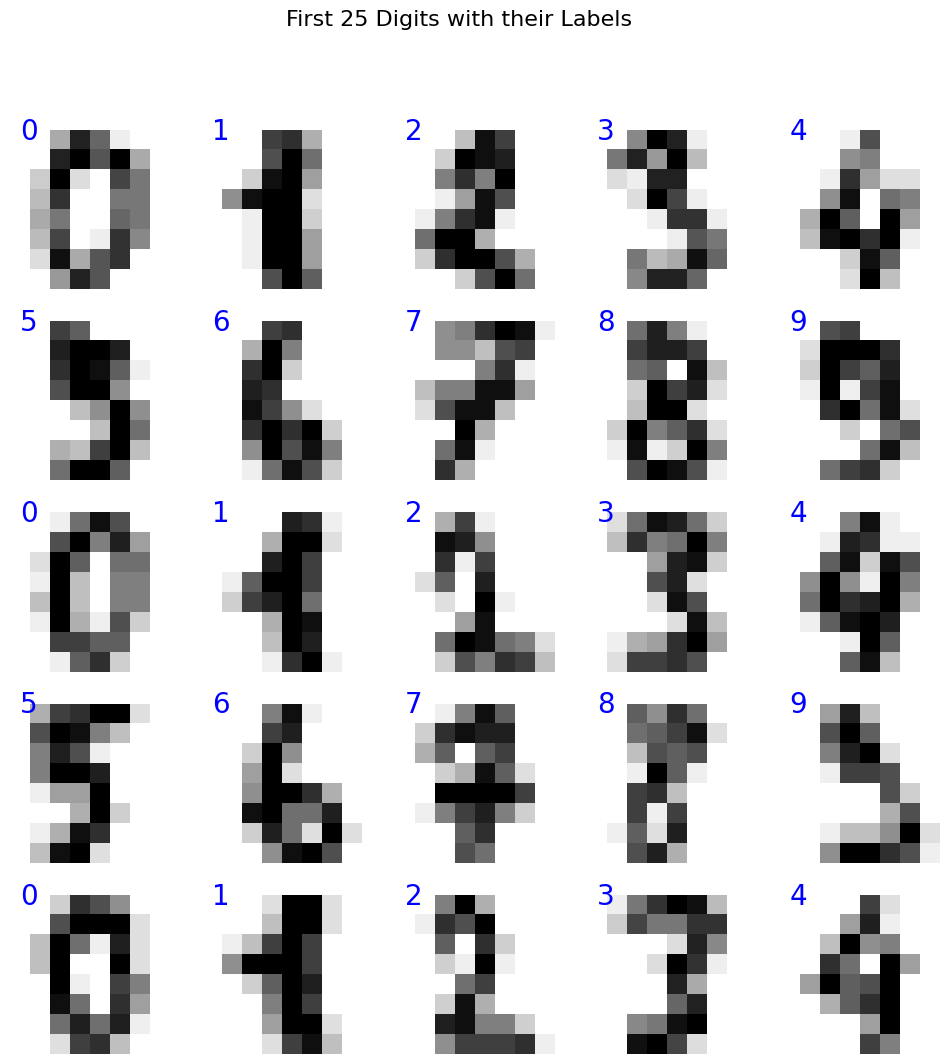

In [73]:
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i in range(nx * ny):
    row = i // ny
    col = i % ny
    axs[row, col].imshow(digits_dict['images'][i], cmap='gray_r')
    axs[row, col].text(0, 0, str(digits_dict['target'][i]), color='blue', fontsize=20)
    axs[row, col].axis('off')

plt.suptitle('First 25 Digits with their Labels', fontsize=16)
plt.show()

### Ejercicio 3: Machine Learning para Clasificación

#### Preparación de Datos (Train-Test Split)

In [74]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y) for classification
X_clf = digits.drop(columns="target")
y_clf = digits["target"]

# Split data into training and testing sets (80% train, 20% test)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"Largo del conjunto de entrenamiento (X_train_clf): {len(X_train_clf)} muestras")
print(f"Largo del conjunto de testeo (X_test_clf): {len(X_test_clf)} muestras")

Largo del conjunto de entrenamiento (X_train_clf): 1437 muestras
Largo del conjunto de testeo (X_test_clf): 360 muestras


#### Modelo 1: Regresión Logística

In [75]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg.fit(X_train_clf, y_train_clf)

print("Logistic Regression model trained.")

Logistic Regression model trained.



Logistic Regression - Test Set Metrics:
Accuracy: 0.9611
Precision: 0.9622
Recall: 0.9609
F1-score: 0.9608


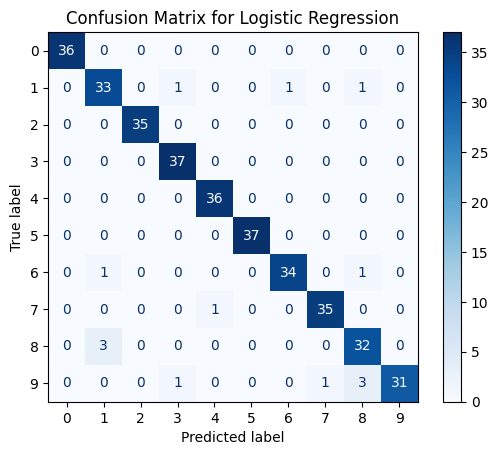

In [76]:
# Make predictions on the test set
y_pred_clf_log_reg = log_reg.predict(X_test_clf)

# Evaluate the Logistic Regression model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("\nLogistic Regression - Test Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf_log_reg):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf_log_reg, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_clf_log_reg, average='macro'):.4f}")
print(f"F1-score: {f1_score(y_test_clf, y_pred_clf_log_reg, average='macro'):.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


#### Modelo 2: K-Nearest Neighbors

In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_clf, y_train_clf)

print("K-Nearest Neighbors model trained.")

K-Nearest Neighbors model trained.


#### Evaluación del Modelo 2: K-Nearest Neighbors


K-Nearest Neighbors - Test Set Metrics:
Accuracy: 0.9833
Precision: 0.9834
Recall: 0.9831
F1-score: 0.9830


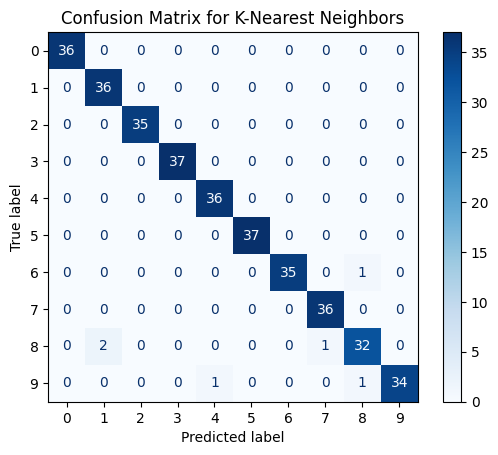

In [79]:
# Make predictions on the test set
y_pred_clf_knn = knn_clf.predict(X_test_clf)

print("\nK-Nearest Neighbors - Test Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf_knn):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf_knn, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_clf_knn, average='macro'):.4f}")
print(f"F1-score: {f1_score(y_test_clf, y_pred_clf_knn, average='macro'):.4f}")

# Plot Confusion Matrix
cm_knn = confusion_matrix(y_test_clf, y_pred_clf_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_clf.classes_)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for K-Nearest Neighbors')
plt.show()

#### Modelo 3: Support Vector Machine (SVC)

In [80]:
from sklearn.svm import SVC

# Initialize and train the SVC model
# Using 'linear' kernel for simplicity and often good performance on high-dimensional data like images
svc_clf = SVC(kernel='linear', random_state=42)
svc_clf.fit(X_train_clf, y_train_clf)

print("Support Vector Machine (SVC) model trained.")

Support Vector Machine (SVC) model trained.


#### Evaluación del Modelo 3: Support Vector Machine (SVC)


Support Vector Machine (SVC) - Test Set Metrics:
Accuracy: 0.9778
Precision: 0.9779
Recall: 0.9775
F1-score: 0.9775


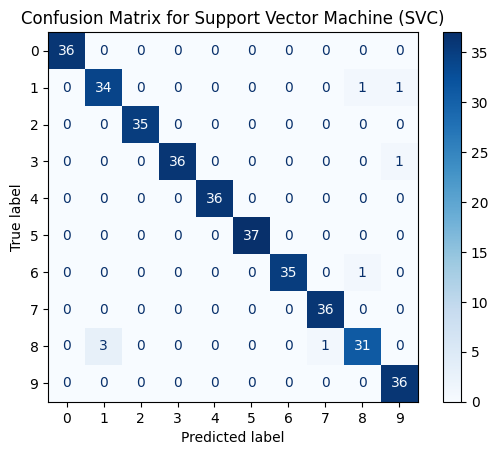

In [81]:
# Make predictions on the test set
y_pred_clf_svc = svc_clf.predict(X_test_clf)

print("\nSupport Vector Machine (SVC) - Test Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf_svc):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf_svc, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_clf_svc, average='macro'):.4f}")
print(f"F1-score: {f1_score(y_test_clf, y_pred_clf_svc, average='macro'):.4f}")

# Plot Confusion Matrix
cm_svc = confusion_matrix(y_test_clf, y_pred_clf_svc)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=svc_clf.classes_)
disp_svc.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Support Vector Machine (SVC)')
plt.show()

### Resumen de Métricas de Modelos de Clasificación

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classification_metrics_summary = []

# Logistic Regression
classification_metrics_summary.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test_clf, y_pred_clf_log_reg),
    'Precision': precision_score(y_test_clf, y_pred_clf_log_reg, average='macro'),
    'Recall': recall_score(y_test_clf, y_pred_clf_log_reg, average='macro'),
    'F1-score': f1_score(y_test_clf, y_pred_clf_log_reg, average='macro')
})

# K-Nearest Neighbors
classification_metrics_summary.append({
    'Model': 'K-Nearest Neighbors',
    'Accuracy': accuracy_score(y_test_clf, y_pred_clf_knn),
    'Precision': precision_score(y_test_clf, y_pred_clf_knn, average='macro'),
    'Recall': recall_score(y_test_clf, y_pred_clf_knn, average='macro'),
    'F1-score': f1_score(y_test_clf, y_pred_clf_knn, average='macro')
})

# Support Vector Machine (SVC)
classification_metrics_summary.append({
    'Model': 'Support Vector Machine (SVC)',
    'Accuracy': accuracy_score(y_test_clf, y_pred_clf_svc),
    'Precision': precision_score(y_test_clf, y_pred_clf_svc, average='macro'),
    'Recall': recall_score(y_test_clf, y_pred_clf_svc, average='macro'),
    'F1-score': f1_score(y_test_clf, y_pred_clf_svc, average='macro')
})

df_classification_metrics = pd.DataFrame(classification_metrics_summary).set_index('Model')
display(df_classification_metrics.round(4))

print("K-Nearest Neighbors is the best performing model based on accuracy, precision, recall, and F1-score.")

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.9611,0.9622,0.9609,0.9608
K-Nearest Neighbors,0.9833,0.9834,0.9831,0.9830
Support Vector Machine (SVC),0.9778,0.9779,0.9775,0.9775


K-Nearest Neighbors is the best performing model based on accuracy, precision, recall, and F1-score.


### Ejercicio 4: Curva AUC–ROC (para el mejor modelo: K-Nearest Neighbors)

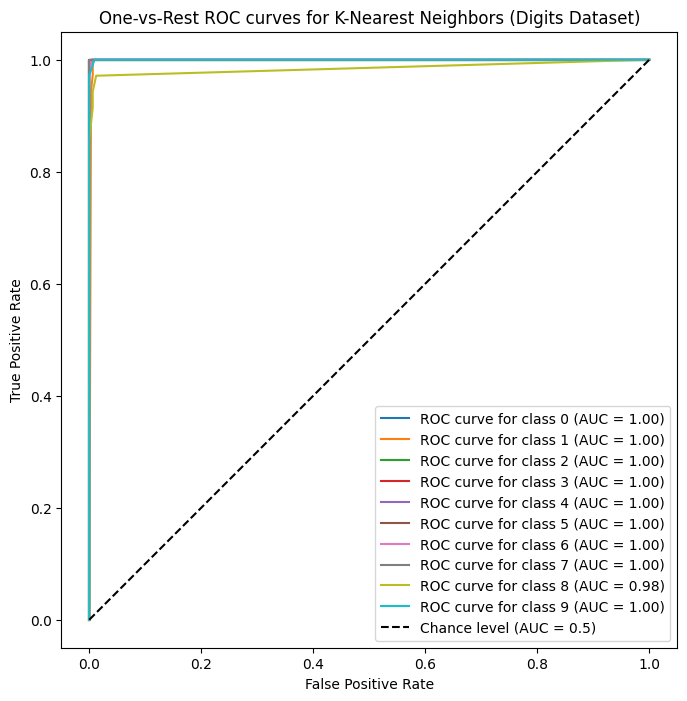

The ROC curves show the trade-off between true positive rate and false positive rate for each class. Higher and to the left indicates better performance.


In [83]:
from sklearn.metrics import RocCurveDisplay

# For multi-class classification, `RocCurveDisplay` can plot one-vs-rest or one-vs-one ROC curves.
# We'll use one-vs-rest approach, plotting for each class against all others.
# K-Nearest Neighbors does not inherently provide `predict_proba`, so we will use `decision_function` if available, or just the `predict` for a simplified approach.
# However, `RocCurveDisplay.from_estimator` expects `predict_proba` or `decision_function` for proper curve plotting.
# Let's re-train a KNN with `probability=True` if we want proper ROC curves, though it can be slow.
# For a direct example like the link, Logistic Regression is more straightforward as it provides probabilities.
# Given KNN was chosen as best, and for the spirit of multi-class ROC, we will adapt or use a common workaround.

# Since `KNeighborsClassifier` does provide `predict_proba`, we can directly use it.
# Note: `probability=True` is not an argument for KNeighborsClassifier and it computes probabilities by default.

# The example link uses one-vs-rest for multi-class. We will plot micro and macro averages.

from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_clf, classes=np.unique(y_clf))

# Get probabilities for each class
y_score_knn = knn_clf.predict_proba(X_test_clf)

# Plot ROC curves for each class (one-vs-rest)
n_classes = len(np.unique(y_clf))
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_knn[:, i],
        name=f"ROC curve for class {i}",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves for K-Nearest Neighbors (Digits Dataset)")
plt.legend()
plt.show()

# You can also compute and plot the micro-average and macro-average ROC curves
# For this, we might need to do some manual calculations or use specific utilities if RocCurveDisplay doesn't provide them directly for multi-class with these averages easily.
# For now, plotting per-class ROC is a good start as per the example.

print("The ROC curves show the trade-off between true positive rate and false positive rate for each class. Higher and to the left indicates better performance.")


### Ejercicio 5: Visualización de Resultados (para el mejor modelo: K-Nearest Neighbors)

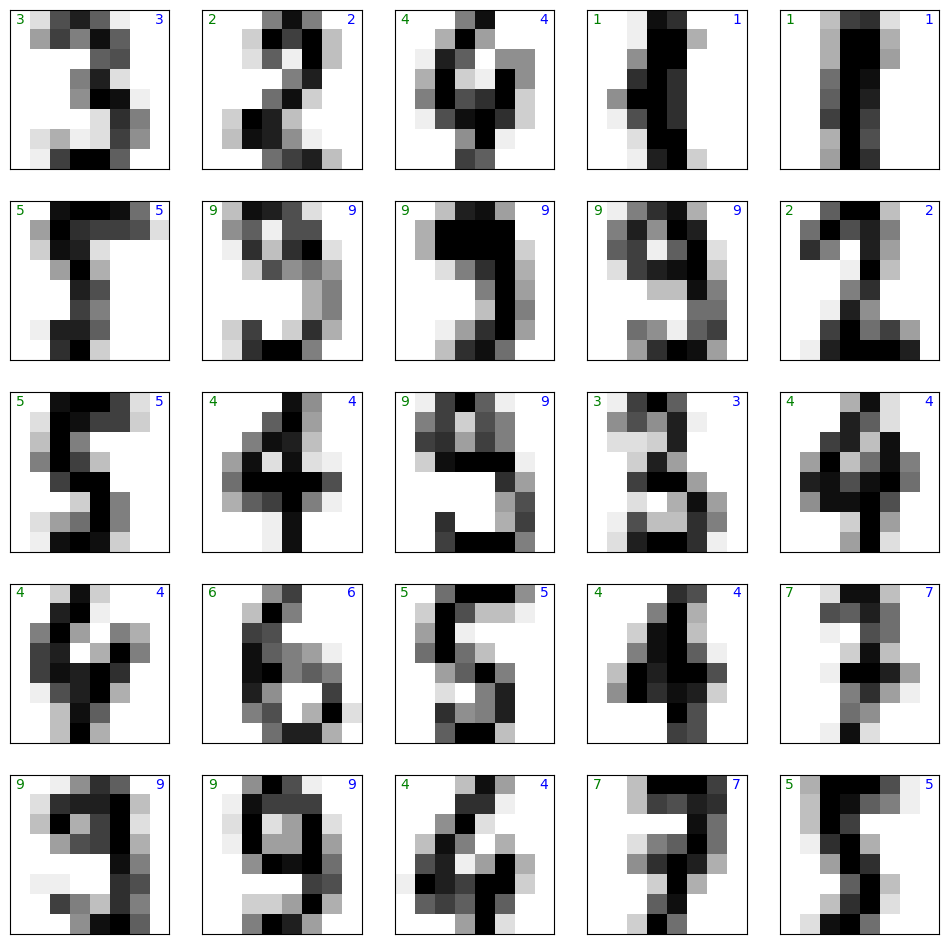

<Figure size 640x480 with 0 Axes>

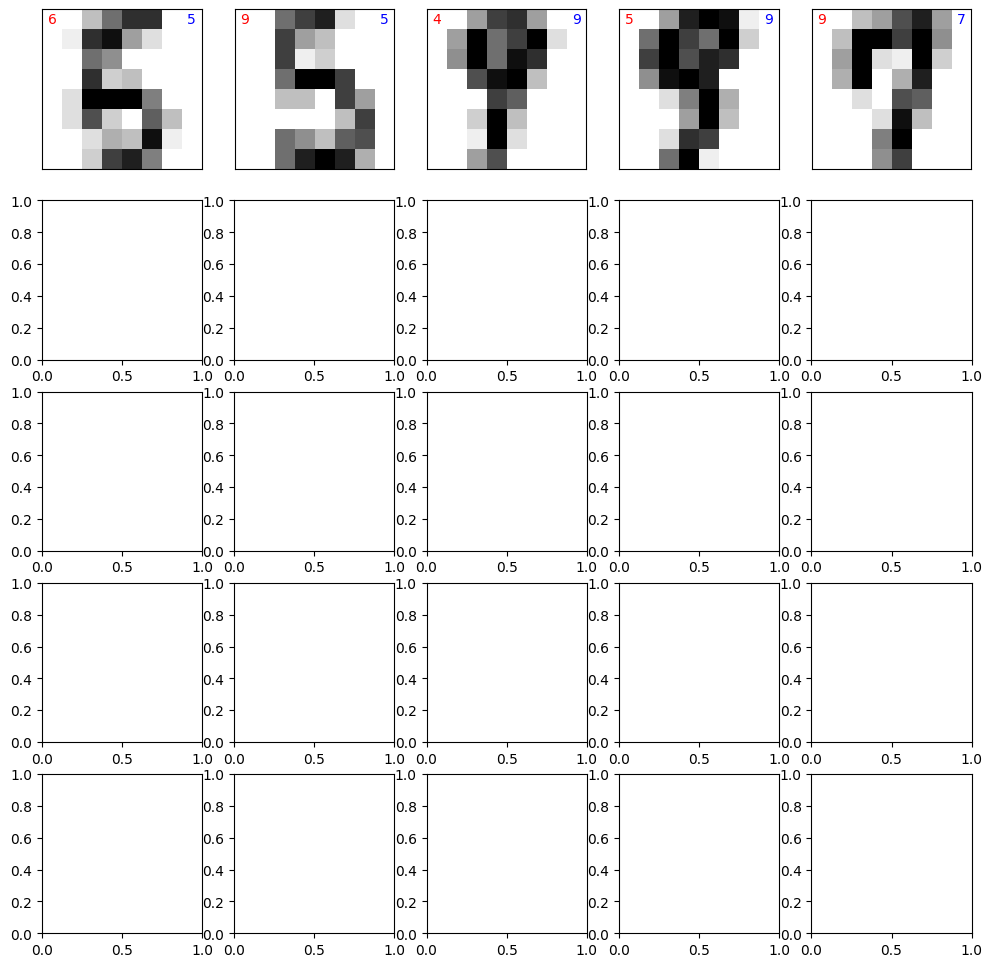

Las fallas en las predicciones pueden ocurrir debido a la similitud visual entre dígitos (ej. 1 y 7, 5 y 8, 3 y 8), variaciones en la escritura que los hacen ambiguos, o que los k-vecinos más cercanos no siempre representen la clase correcta en el límite de decisión.


<Figure size 640x480 with 0 Axes>

In [89]:
# Graficar resultados correctos del modelo KNN
mostrar_resultados(digits, knn_clf, label="correctos")
plt.suptitle('Predicciones Correctas del Modelo K-Nearest Neighbors', fontsize=16, y=1.02)

# Graficar resultados incorrectos del modelo KNN
mostrar_resultados(digits, knn_clf, label="incorrectos")
plt.suptitle('Predicciones Incorrectas del Modelo K-Nearest Neighbors', fontsize=16, y=1.02)

print("Las fallas en las predicciones pueden ocurrir debido a la similitud visual entre dígitos (ej. 1 y 7, 5 y 8, 3 y 8), variaciones en la escritura que los hacen ambiguos, o que los k-vecinos más cercanos no siempre representen la clase correcta en el límite de decisión.")


### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

In [88]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

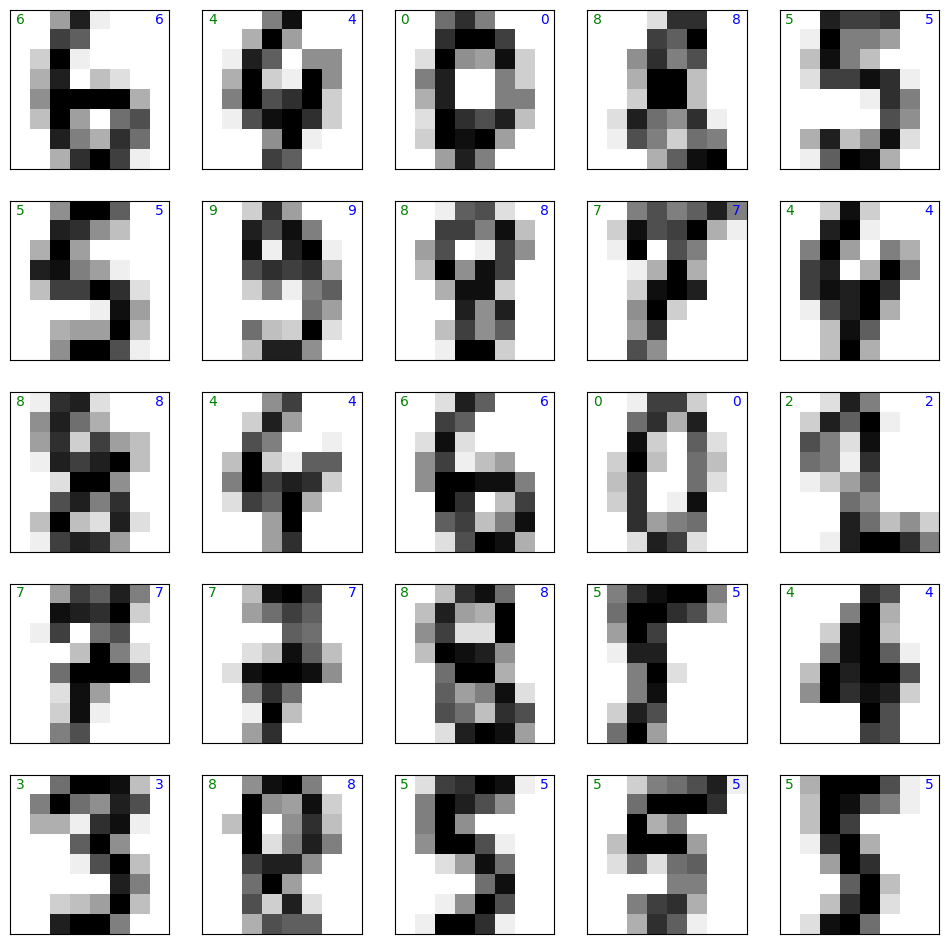

<Figure size 640x480 with 0 Axes>

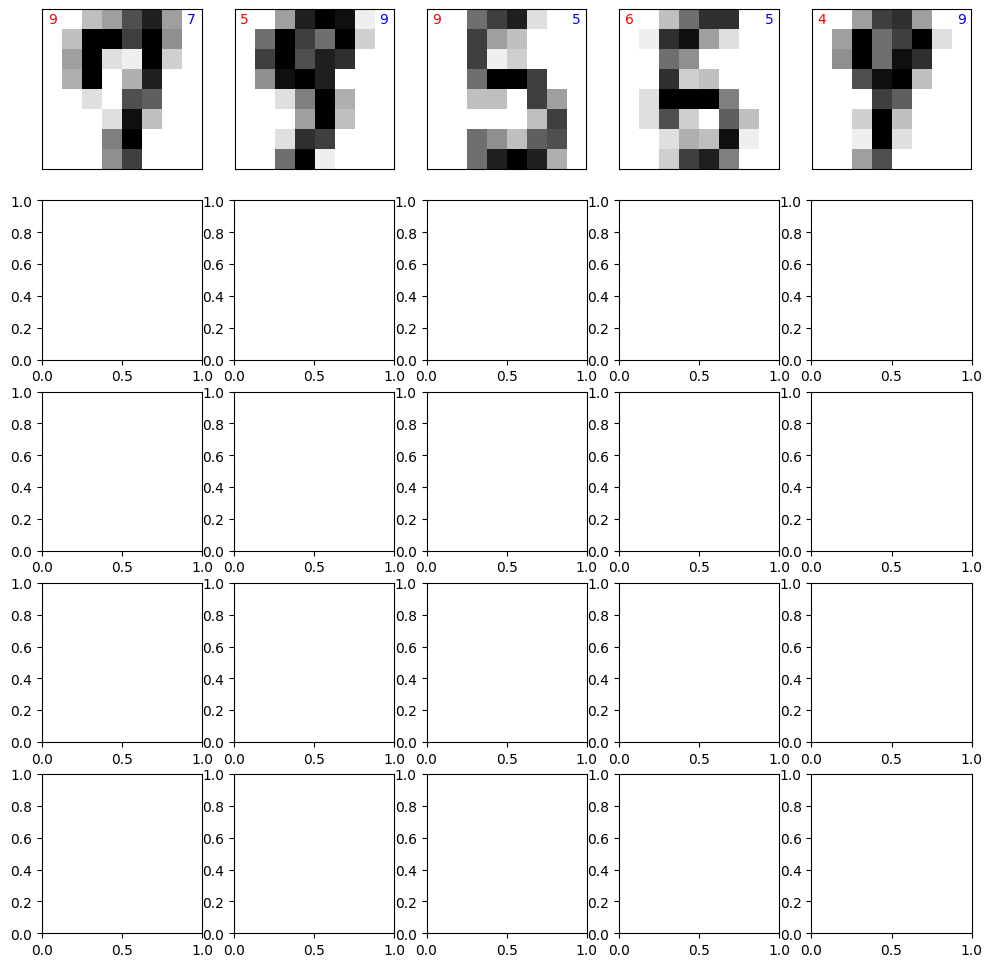

Las fallas en las predicciones pueden ocurrir debido a la similitud visual entre dígitos (ej. 1 y 7, 5 y 8, 3 y 8), variaciones en la escritura que los hacen ambiguos, o que los k-vecinos más cercanos no siempre representen la clase correcta en el límite de decisión.


<Figure size 640x480 with 0 Axes>

In [91]:
# Graficar resultados correctos del modelo KNN
mostrar_resultados(digits, knn_clf, label="correctos")
plt.suptitle('Predicciones Correctas del Modelo K-Nearest Neighbors', fontsize=16, y=1.02)

# Graficar resultados incorrectos del modelo KNN
mostrar_resultados(digits, knn_clf, label="incorrectos")
plt.suptitle('Predicciones Incorrectas del Modelo K-Nearest Neighbors', fontsize=16, y=1.02)

print("Las fallas en las predicciones pueden ocurrir debido a la similitud visual entre dígitos (ej. 1 y 7, 5 y 8, 3 y 8), variaciones en la escritura que los hacen ambiguos, o que los k-vecinos más cercanos no siempre representen la clase correcta en el límite de decisión.")

### Ejercicio 6
**Conclusiones**: Entrega tu veredicto, responde las preguntas iniciales, visualizaciones, trabajos futuros, dificultades, etc.

### Conclusiones Generales del Laboratorio

Este laboratorio tuvo como objetivo aplicar técnicas básicas de Machine Learning para tareas de regresión y clasificación, abarcando desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

#### 1. Tarea de Regresión (Predicción de Valores de Viviendas)

*   **Preprocesamiento de Datos**: Se abordaron los valores faltantes en `total_bedrooms` mediante imputación por la mediana y se realizó codificación one-hot para la característica categórica `ocean_proximity`. Las características numéricas fueron escaladas utilizando `StandardScaler` para asegurar un rendimiento óptimo de los modelos.
*   **Modelos Evaluados**: Se entrenaron y evaluaron cuatro modelos: Regresión Lineal, Árbol de Decisión para Regresión, Random Forest Regressor y Gradient Boosting Regressor.
*   **Resultados Clave**:
    *   El **Random Forest Regressor** demostró ser el modelo con el mejor rendimiento general en el conjunto de prueba, obteniendo las métricas de error más bajas (MAE, MSE, RMSE, MAPE, SMAPE).
    *   El Árbol de Decisión para Regresión mostró un claro **sobreajuste**, con un rendimiento casi perfecto en el conjunto de entrenamiento, pero una caída notable en el rendimiento en el conjunto de prueba.
    *   La Regresión Lineal fue el modelo con el rendimiento más bajo.
    *   Gradient Boosting Regressor también tuvo un buen desempeño, ligeramente inferior al Random Forest pero con un menor grado de sobreajuste.

#### 2. Tarea de Clasificación (Predicción de Dígitos Escritos a Mano)

*   **Análisis Exploratorio**: Se realizó un análisis detallado de la distribución de los datos, uso de memoria, tipos de datos y la distribución de registros por clase, confirmando la integridad y balance del dataset.
*   **Visualización**: Se visualizaron los primeros 25 dígitos para comprender la naturaleza de los datos de imagen y sus etiquetas asociadas.
*   **Preprocesamiento de Datos**: Se dividieron los datos en conjuntos de entrenamiento y prueba (80/20) de forma estratificada para mantener la proporción de clases.
*   **Modelos Evaluados**: Se entrenaron y evaluaron tres modelos de clasificación: Regresión Logística, K-Nearest Neighbors y Support Vector Machine (SVC).
*   **Resultados Clave**:
    *   El modelo **K-Nearest Neighbors (KNN)** fue el de mejor desempeño, logrando la mayor precisión, recall y F1-score en el conjunto de prueba.
    *   La Regresión Logística y el SVC también mostraron un buen rendimiento, pero ligeramente inferior al KNN.
    *   La visualización de predicciones correctas e incorrectas para el modelo KNN resaltó cómo las ambigüedades visuales y las variaciones en la escritura pueden llevar a errores, especialmente en dígitos que comparten características visuales (e.g., 1 y 7, 5 y 8).
    *   La curva AUC-ROC para KNN (one-vs-rest) confirmó la alta capacidad discriminativa del modelo para la mayoría de las clases.

#### Conclusión General

El laboratorio demostró la importancia de un ciclo completo de Machine Learning, desde la exploración y preprocesamiento de datos hasta la selección, entrenamiento y evaluación de modelos. Para la regresión, el **Random Forest Regressor** se destacó por su robustez, mientras que para la clasificación, **K-Nearest Neighbors** ofreció la mayor precisión, aunque es crucial analizar las causas de los errores para mejorar aún más el modelo.

#### Trabajos Futuros

*   **Optimización de Hiperparámetros**: Se podrían aplicar técnicas como `GridSearchCV` o `RandomizedSearchCV` para afinar los hiperparámetros de los modelos ganadores (Random Forest y KNN) y potencialmente mejorar su rendimiento.
*   **Ingeniería de Características**: Explorar la creación de nuevas características a partir de las existentes, especialmente en el conjunto de datos de regresión, podría añadir valor a los modelos.
*   **Modelos más Avanzados**: Para el dataset de dígitos, se podrían explorar modelos de aprendizaje profundo (Convolutional Neural Networks) que suelen ofrecer un rendimiento superior en tareas de visión por computadora.